# Versão comentada célula por célula

Este notebook mantém a estrutura do projeto ENEM e acrescenta comentários explicativos nas células de código, com foco em leitura, tratamento, rankings e geração de gráficos com Matplotlib.


# CELULA 01: Importação das bibliotecas
Recupere os microdados e localize o arquivo que contém os resultados individuais de todos os
inscritos no exame. Identifique, através da documentação e do próprio arquivo, as colunas que
trazem os seguintes dados:
1. Notas das provas específicas e notas da redação
2. UF, Cidade e Escola de origem do aluno
3. Tipo de Escola (privada, pública, …)
Faça uma carga parcial do arquivo, tratando apenas dessas colunas. Identifique dados
inconsistentes ou faltantes. Produza dados agregados a partir dos dados brutos:
a) Média de notas por aluno
b) Média de notas por escola
c) Média de notas por município
d) Média de notas por UF
Produza um ranking dos 10 melhores alunos, 10 melhores escolas (geral e nos extratos
públicos e privado) e 10 melhores municípios do país e do Rio Grande do Sul.


# CELULA 01: Importação das bibliotecas
Nesta etapa serão importadas as bibliotecas Pandas e NumPy para tratamento dos dados.

In [1]:
# Importa a biblioteca Pandas, usada para ler, organizar, filtrar e analisar tabelas de dados.
# Neste projeto, o Pandas será usado para trabalhar com os microdados do ENEM em formato CSV.
import pandas as pd

# Importa a biblioteca NumPy, usada para operações numéricas.
# Aqui ela será útil principalmente em gráficos e no tratamento de valores numéricos ausentes.
import numpy as np


# CELULA 02: Leitura parcial dos microdados
Como os microdados do ENEM possuem tamanho elevado, será feita uma leitura parcial das colunas necessárias.
Essas colunas atendem ao núcleo do projeto: notas específicas, redação, UF, município e tipo de escola. A parte “cidade e escola de origem” pode exigir cuidado, porque em algumas versões dos microdados há restrições/supressões por LGPD; o próprio INEP informa que os formatos dos microdados vêm sendo reestruturados para reduzir possibilidade de identificação de pessoas.

Criamos as variaveis 'coluna=' e 'caminho=' para simplificas a sintaxe, quando usamos nos comandos


In [ ]:
# Define o caminho do arquivo CSV que contém os resultados individuais do ENEM.
# ATENÇÃO: este caminho deve ser alterado caso o arquivo esteja em outra pasta do seu computador. Usar /.
caminho = "C:/Users/enggi/IA_CURSO/ALGORITMO PROGRAMACAO APE/AULA06/RESULTADOS_2024.csv"

# Lista com as colunas que serão carregadas do arquivo original.
# Como os microdados do ENEM são muito grandes, selecionar apenas as colunas necessárias
# deixa a leitura mais rápida e economiza memória do computador.
colunas_resul = [
    # -------------------------------------------------------------------------
    # Identificação do participante
    # -------------------------------------------------------------------------
    "NU_SEQUENCIAL",  # Número sequencial/identificador do aluno na base de dados.

    # -------------------------------------------------------------------------
    # Localização da escola de origem do participante
    # -------------------------------------------------------------------------
    "SG_UF_ESC",         # Sigla da Unidade Federativa da escola. Exemplo: RS, SP, MG.
    "NO_MUNICIPIO_ESC",  # Nome do município da escola de origem do aluno.

    # -------------------------------------------------------------------------
    # Informações da escola
    # -------------------------------------------------------------------------
    "TP_DEPENDENCIA_ADM_ESC",  # Tipo de dependência administrativa da escola.
                                # 1 = Federal, 2 = Estadual, 3 = Municipal, 4 = Privada.
    "CO_ESCOLA",               # Código da escola no cadastro utilizado nos microdados.

    # -------------------------------------------------------------------------
    # Notas das provas objetivas
    # -------------------------------------------------------------------------
    "NU_NOTA_CN",  # Nota de Ciências da Natureza.
    "NU_NOTA_CH",  # Nota de Ciências Humanas.
    "NU_NOTA_LC",  # Nota de Linguagens e Códigos.
    "NU_NOTA_MT",  # Nota de Matemática.

    # -------------------------------------------------------------------------
    # Nota da redação
    # -------------------------------------------------------------------------
    "NU_NOTA_REDACAO"  # Nota da redação.
]

# Dicionário que define o tipo de dado de algumas colunas numéricas.
# O tipo float32 ocupa menos memória do que float64.
# Isso é importante porque os microdados do ENEM podem ter milhões de linhas.
dtypes_resul = {
    "NU_NOTA_CN": "float32",
    "NU_NOTA_CH": "float32",
    "NU_NOTA_LC": "float32",
    "NU_NOTA_MT": "float32",
}

# Lê o arquivo CSV com a função read_csv() do Pandas.
df = pd.read_csv(
    caminho,              # Caminho onde o arquivo CSV está salvo.
    sep=";",              # Os microdados do ENEM normalmente usam ponto e vírgula como separador.
    encoding="latin1",    # Codificação que evita erros com acentos e caracteres especiais.
    usecols=colunas_resul, # Lê somente as colunas escolhidas na lista colunas_resul.
    dtype=dtypes_resul,   # Aplica os tipos numéricos definidos em dtypes_resul.
    nrows=100_000         # Lê somente as primeiras 100 mil linhas para teste e desenvolvimento.
)

# Mostra as 5 primeiras linhas do DataFrame.
# Isso permite conferir se o arquivo foi carregado corretamente.
df.head()


,NU_SEQUENCIAL,CO_ESCOLA,NO_MUNICIPIO_ESC,SG_UF_ESC,TP_DEPENDENCIA_ADM_ESC,NU_NOTA_CN,NU_NOTA_CH,NU_NOTA_LC,NU_NOTA_MT,NU_NOTA_REDACAO
0,206403,23052929.0,Aratuba,CE,2.0,436.799988,377.799988,423.399994,427.100006,300.0
1,3604651,42103770.0,Tijucas,SC,4.0,521.900024,601.900024,605.500000,689.200012,920.0
2,1461268,NaN,NaN,NaN,NaN,363.000000,548.400024,557.200012,456.399994,480.0
3,4301058,NaN,NaN,NaN,NaN,550.700012,553.799988,605.900024,629.099976,740.0
4,3148322,21150354.0,Alto Alegre do Maranhão,MA,2.0,NaN,NaN,NaN,NaN,NaN


# CELULA 03
Verificação de dados faltantes

In [3]:
# Mostra um resumo geral do DataFrame.
# O método info() informa:
# - quantidade de linhas;
# - quantidade de colunas;
# - nome de cada coluna;
# - quantidade de valores não nulos;
# - tipo de dado de cada coluna.
df.info()

# Conta a quantidade de dados faltantes em cada coluna.
# Um valor faltante aparece como NaN no Pandas.
df.isnull().sum()

# Calcula o percentual de dados faltantes em cada coluna.
# mean() considera True como 1 e False como 0.
# Assim, df.isnull().mean() retorna a proporção de valores ausentes.
df.isnull().mean() * 100


<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 10 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   NU_SEQUENCIAL           100000 non-null  int64  
 1   CO_ESCOLA               36232 non-null   float64
 2   NO_MUNICIPIO_ESC        36232 non-null   str    
 3   SG_UF_ESC               36232 non-null   str    
 4   TP_DEPENDENCIA_ADM_ESC  36232 non-null   float64
 5   NU_NOTA_CN              69121 non-null   float32
 6   NU_NOTA_CH              73025 non-null   float32
 7   NU_NOTA_LC              73025 non-null   float32
 8   NU_NOTA_MT              69121 non-null   float32
 9   NU_NOTA_REDACAO         73025 non-null   float64
dtypes: float32(4), float64(3), int64(1), str(2)
memory usage: 6.1 MB


NU_SEQUENCIAL              0.000
CO_ESCOLA                 63.768
NO_MUNICIPIO_ESC          63.768
SG_UF_ESC                 63.768
TP_DEPENDENCIA_ADM_ESC    63.768
NU_NOTA_CN                30.879
NU_NOTA_CH                26.975
NU_NOTA_LC                26.975
NU_NOTA_MT                30.879
NU_NOTA_REDACAO           26.975
dtype: float64

# CELULA 04 
Ver em porcentagem os dados faltantes

In [5]:
# Calcula o percentual de valores faltantes em cada coluna do DataFrame.
# Esse resultado ajuda a identificar quais colunas possuem muitos dados ausentes.
faltantes_percentual = df.isnull().mean() * 100

# Arredonda o percentual para duas casas decimais.
# Isso deixa a visualização mais limpa e adequada para análise ou relatório.
faltantes_percentual.round(2)


NU_SEQUENCIAL              0.00
CO_ESCOLA                 63.77
NO_MUNICIPIO_ESC          63.77
SG_UF_ESC                 63.77
TP_DEPENDENCIA_ADM_ESC    63.77
NU_NOTA_CN                30.88
NU_NOTA_CH                26.98
NU_NOTA_LC                26.98
NU_NOTA_MT                30.88
NU_NOTA_REDACAO           26.98
dtype: float64

# CELULA 05 - Criar média por aluno
Cria uma lista chamada 'colunas_notas' contendo os nomes das colunas
que armazenam as notas do ENEM.
Essas colunas serão usadas para calcular a média de cada aluno.

In [6]:
# Lista com as colunas de notas que serão usadas para calcular a média geral do aluno.
# A média será calculada usando as quatro provas objetivas e a redação.
colunas_notas = [
    "NU_NOTA_CN",       # Nota de Ciências da Natureza.
    "NU_NOTA_CH",       # Nota de Ciências Humanas.
    "NU_NOTA_LC",       # Nota de Linguagens e Códigos.
    "NU_NOTA_MT",       # Nota de Matemática.
    "NU_NOTA_REDACAO"   # Nota da Redação.
]

# Cria uma nova coluna no DataFrame chamada MEDIA_ALUNO.
# df[colunas_notas] seleciona somente as colunas de notas.
# mean(axis=1) calcula a média linha por linha, ou seja, calcula uma média para cada aluno.
# O eixo axis=1 significa que o cálculo será feito horizontalmente, entre as colunas da mesma linha.
df["MEDIA_ALUNO"] = df[colunas_notas].mean(axis=1)

# Exibe apenas o identificador do aluno e a média calculada.
# head() mostra as 5 primeiras linhas para conferência.
df[["NU_SEQUENCIAL", "MEDIA_ALUNO"]].head()


,NU_SEQUENCIAL,MEDIA_ALUNO
0,206403,393.019995
1,3604651,667.700012
2,1461268,481.000006
3,4301058,615.900000
4,3148322,NaN


# CELULA 06 - Ranking dos 10 melhores alunos
Crio a variavel 'ranking_alunos=', comando 'df.sort_values é um método do Pandas para Ordenar o DataFrame com base na coluna "MEDIA_ALUNO".
O parâmetro by="MEDIA_ALUNO" indica que a ordenação será feita pela média dos alunos.
O parâmetro ascending=False indica ordem decrescente, ou seja,
os alunos com maiores médias aparecem primeiro.
O método .head(10) seleciona apenas os 10 primeiros registros após a ordenação.


In [7]:
# Esta célula cria o ranking individual dos alunos com maiores médias.
# A coluna usada para ordenar os alunos é MEDIA_ALUNO, criada na célula anterior.

# sort_values() ordena o DataFrame conforme uma coluna escolhida.
# by="MEDIA_ALUNO" indica que a ordenação será feita pela média geral do aluno.
# ascending=False indica ordem decrescente, isto é, da maior média para a menor.
# head(10) seleciona somente os 10 primeiros alunos após a ordenação.
ranking_alunos = df.sort_values(
    by="MEDIA_ALUNO",
    ascending=False
).head(10)

# Imprime uma mensagem antes de exibir a tabela.
print("Ranking dos 10 melhores alunos:")

# Exibe somente as colunas mais importantes para interpretar o ranking.
# Como os microdados não trazem o nome do aluno, usamos NU_SEQUENCIAL como identificação.
ranking_alunos[
    [
        "NU_SEQUENCIAL",            # Identificador do aluno na base.
        "SG_UF_ESC",                # UF da escola de origem.
        "NO_MUNICIPIO_ESC",         # Município da escola de origem.
        "CO_ESCOLA",                # Código da escola.
        "TP_DEPENDENCIA_ADM_ESC",   # Tipo administrativo da escola.
        "MEDIA_ALUNO"               # Média geral calculada do aluno.
    ]
]


Ranking dos 10 melhores alunos:


,NU_SEQUENCIAL,SG_UF_ESC,NO_MUNICIPIO_ESC,CO_ESCOLA,TP_DEPENDENCIA_ADM_ESC,MEDIA_ALUNO
48847,410981,CE,Fortaleza,23564121.0,4.0,825.940002
59347,2174880,NaN,NaN,NaN,NaN,822.080005
34289,833685,NaN,NaN,NaN,NaN,820.619995
65605,2740037,NaN,NaN,NaN,NaN,817.260010
84687,1386260,NaN,NaN,NaN,NaN,817.199988
54615,103204,NaN,NaN,NaN,NaN,816.500012
63509,3430345,NaN,NaN,NaN,NaN,816.000000
18278,820758,NaN,NaN,NaN,NaN,815.019995
90921,82460,NaN,NaN,NaN,NaN,814.620007
30817,248857,NaN,NaN,NaN,NaN,812.379993


# CELULA 07 - Preparação dos dados para rankings agregados
Nesta etapa será criada uma cópia do DataFrame apenas com alunos que possuem média calculada. Também será criada uma coluna com o nome do tipo de escola, facilitando a interpretação dos rankings e dos gráficos.


In [8]:
# Esta célula prepara uma versão mais limpa do DataFrame para rankings e gráficos.
# O objetivo é evitar que alunos sem média calculada entrem nas análises.

# dropna(subset=["MEDIA_ALUNO"]) remove linhas em que MEDIA_ALUNO está vazia.
# copy() cria uma cópia independente do DataFrame filtrado.
# Isso evita alguns avisos do Pandas ao criar novas colunas.
df_validos = df.dropna(subset=["MEDIA_ALUNO"]).copy()

# Dicionário para traduzir os códigos da coluna TP_DEPENDENCIA_ADM_ESC.
# Essa tradução facilita a leitura dos resultados e dos gráficos.
mapa_dependencia = {
    1: "Federal",
    2: "Estadual",
    3: "Municipal",
    4: "Privada"
}

# Cria a coluna TIPO_ESCOLA com os nomes das categorias.
# map() substitui os códigos numéricos pelo texto definido no dicionário mapa_dependencia.
df_validos["TIPO_ESCOLA"] = df_validos["TP_DEPENDENCIA_ADM_ESC"].map(mapa_dependencia)

# Exibe as primeiras linhas para verificar se a coluna TIPO_ESCOLA foi criada corretamente.
df_validos.head()


,NU_SEQUENCIAL,CO_ESCOLA,NO_MUNICIPIO_ESC,SG_UF_ESC,TP_DEPENDENCIA_ADM_ESC,NU_NOTA_CN,NU_NOTA_CH,NU_NOTA_LC,NU_NOTA_MT,NU_NOTA_REDACAO,MEDIA_ALUNO,TIPO_ESCOLA
0,206403,23052929.0,Aratuba,CE,2.0,436.799988,377.799988,423.399994,427.100006,300.0,393.019995,Estadual
1,3604651,42103770.0,Tijucas,SC,4.0,521.900024,601.900024,605.500000,689.200012,920.0,667.700012,Privada
2,1461268,NaN,NaN,NaN,NaN,363.000000,548.400024,557.200012,456.399994,480.0,481.000006,NaN
3,4301058,NaN,NaN,NaN,NaN,550.700012,553.799988,605.900024,629.099976,740.0,615.900000,NaN
6,3587454,15585689.0,Belém,PA,4.0,486.700012,NaN,NaN,525.099976,NaN,505.899994,Privada


# CELULA 08 - Média de notas por escola
Agrupa os alunos por escola, calcula a média da coluna `MEDIA_ALUNO` e conta quantos alunos aparecem em cada escola no recorte carregado.


In [9]:
# Esta célula calcula a média dos alunos por escola.
# A análise por escola precisa de cuidado, pois uma escola com poucos alunos pode aparecer
# artificialmente no topo do ranking se apenas um aluno tiver nota muito alta.

# Define o número mínimo de alunos por escola para ela participar do ranking.
# Neste exemplo, a escola precisa ter pelo menos 3 alunos na amostra analisada.
minimo_alunos_escola = 3

# Agrupa os dados por escola e calcula duas informações:
# - MEDIA_ESCOLA: média da coluna MEDIA_ALUNO em cada escola;
# - QT_ALUNOS: quantidade de alunos considerados em cada escola.
media_escola = (
    df_validos
    # Remove linhas sem código de escola, pois não seria possível identificar a escola.
    .dropna(subset=["CO_ESCOLA"])

    # Agrupa por código da escola, UF, município e tipo de dependência administrativa.
    .groupby(["CO_ESCOLA", "SG_UF_ESC", "NO_MUNICIPIO_ESC", "TP_DEPENDENCIA_ADM_ESC", "TIPO_ESCOLA"])

    # Calcula estatísticas para cada grupo/escola.
    .agg(
        MEDIA_ESCOLA=("MEDIA_ALUNO", "mean"),  # Média dos alunos da escola.
        QT_ALUNOS=("MEDIA_ALUNO", "count")     # Quantidade de alunos da escola na amostra.
    )

    # Transforma os índices do agrupamento novamente em colunas normais.
    .reset_index()
)

# Mantém somente as escolas com quantidade de alunos maior ou igual ao mínimo definido.
media_escola_filtrada = media_escola[media_escola["QT_ALUNOS"] >= minimo_alunos_escola]

# Cria o ranking geral das 10 escolas com maiores médias.
ranking_escolas_geral = (
    media_escola_filtrada
    .sort_values(by="MEDIA_ESCOLA", ascending=False)
    .head(10)
)

# Exibe o ranking geral das escolas.
ranking_escolas_geral


,CO_ESCOLA,SG_UF_ESC,NO_MUNICIPIO_ESC,TP_DEPENDENCIA_ADM_ESC,TIPO_ESCOLA,MEDIA_ESCOLA,QT_ALUNOS
7816,33176825.0,RJ,Rio de Janeiro,4.0,Privada,761.379996,4
6615,31333921.0,MG,Nova Lima,4.0,Privada,752.755002,4
6965,32078498.0,ES,Vila Velha,1.0,Federal,744.646659,3
10164,35445848.0,SP,Araraquara,4.0,Privada,742.853328,3
4020,26181231.0,PE,Recife,4.0,Privada,740.265002,4
5480,31004812.0,MG,Belo Horizonte,4.0,Privada,739.951997,5
1827,22025740.0,PI,Teresina,4.0,Privada,737.244001,5
10209,35463279.0,SP,São Paulo,4.0,Privada,736.729999,4
13735,53013085.0,DF,Brasília,4.0,Privada,734.779997,3
7924,33447225.0,RJ,Rio de Janeiro,4.0,Privada,731.171997,5


# CELULA 09 - Ranking das 10 melhores escolas públicas e privadas
Nesta etapa são criados dois rankings separados: um para escolas públicas e outro para escolas privadas. Foram consideradas públicas as escolas federais, estaduais e municipais.


In [10]:
# Esta célula cria o ranking das escolas públicas.
# Nos microdados usados neste projeto:
# 1 = Federal, 2 = Estadual, 3 = Municipal.

# Filtra somente escolas públicas usando isin([1, 2, 3]).
# isin() verifica se o valor da coluna está dentro da lista informada.
escolas_publicas = media_escola_filtrada[
    media_escola_filtrada["TP_DEPENDENCIA_ADM_ESC"].isin([1, 2, 3])
]

# Ordena as escolas públicas pela média, da maior para a menor,
# e seleciona as 10 primeiras.
ranking_escolas_publicas = (
    escolas_publicas
    .sort_values(by="MEDIA_ESCOLA", ascending=False)
    .head(10)
)

# Exibe uma mensagem e, em seguida, a tabela com o ranking.
print("Ranking das 10 melhores escolas públicas:")
ranking_escolas_publicas


Ranking das 10 melhores escolas públicas:


,CO_ESCOLA,SG_UF_ESC,NO_MUNICIPIO_ESC,TP_DEPENDENCIA_ADM_ESC,TIPO_ESCOLA,MEDIA_ESCOLA,QT_ALUNOS
6965,32078498.0,ES,Vila Velha,1.0,Federal,744.646659,3
6081,31128074.0,MG,Viçosa,1.0,Federal,722.893337,6
11369,41148851.0,PR,Curitiba,1.0,Federal,721.620007,3
9158,35045949.0,SP,Campinas,2.0,Estadual,702.819999,3
12337,43105009.0,RS,Porto Alegre,1.0,Federal,691.733332,6
5383,31000019.0,MG,Belo Horizonte,1.0,Federal,686.826672,3
2084,22256725.0,PI,Teresina,2.0,Estadual,683.559996,3
2541,23210710.0,CE,Fortaleza,1.0,Federal,681.674997,4
11993,43000304.0,RS,Pelotas,2.0,Estadual,681.145001,4
7430,33071829.0,RJ,Rio de Janeiro,1.0,Federal,675.293331,3


In [ ]:
# Esta célula cria o ranking das escolas privadas.
# Nos microdados usados neste projeto, o código 4 representa escola privada.

# Filtra somente as escolas privadas.
escolas_privadas = media_escola_filtrada[
    media_escola_filtrada["TP_DEPENDENCIA_ADM_ESC"] == 4
]

# Ordena as escolas privadas pela média, da maior para a menor,
# e seleciona as 10 primeiras.
ranking_escolas_privadas = (
    escolas_privadas
    .sort_values(by="MEDIA_ESCOLA", ascending=False)
    .head(10)
)

# Exibe uma mensagem e a tabela com o ranking.
print("Ranking das 10 melhores escolas privadas:")
ranking_escolas_privadas


# CELULA 10 - Média de notas por município
Agora os dados são agrupados por UF e município da escola. O objetivo é gerar um ranking dos municípios com maiores médias no país e, depois, um ranking específico para o Rio Grande do Sul.


In [11]:
# Esta célula calcula a média dos alunos por município.
# O agrupamento considera a UF e o município da escola.

# Define o número mínimo de alunos por município para entrar no ranking.
# Isso evita que municípios com poucos alunos distorçam a análise.
minimo_alunos_municipio = 10

# Agrupa os dados por UF e município da escola.
media_municipio = (
    df_validos
    # Remove registros sem UF ou sem município da escola.
    .dropna(subset=["SG_UF_ESC", "NO_MUNICIPIO_ESC"])

    # Agrupa por UF e município.
    .groupby(["SG_UF_ESC", "NO_MUNICIPIO_ESC"])

    # Calcula a média do município e a quantidade de alunos.
    .agg(
        MEDIA_MUNICIPIO=("MEDIA_ALUNO", "mean"),
        QT_ALUNOS=("MEDIA_ALUNO", "count")
    )

    # Volta o resultado para o formato de tabela comum.
    .reset_index()
)

# Filtra somente municípios com pelo menos o número mínimo de alunos definido.
media_municipio_filtrada = media_municipio[
    media_municipio["QT_ALUNOS"] >= minimo_alunos_municipio
]

# Cria o ranking dos 10 municípios com maiores médias no conjunto analisado.
ranking_municipios_brasil = (
    media_municipio_filtrada
    .sort_values(by="MEDIA_MUNICIPIO", ascending=False)
    .head(10)
)

# Exibe o ranking dos municípios.
print("Ranking dos 10 melhores municípios do país:")
ranking_municipios_brasil


Ranking dos 10 melhores municípios do país:


,SG_UF_ESC,NO_MUNICIPIO_ESC,MEDIA_MUNICIPIO,QT_ALUNOS
1416,MG,Nova Lima,645.905457,11
1613,MG,Viçosa,637.285002,20
1584,MG,Timóteo,632.990004,14
1469,MG,Ponte Nova,625.729998,10
1344,MG,João Monlevade,618.527999,10
315,BA,Irecê,615.003332,18
3594,SP,Rio Claro,611.596298,27
3643,SP,São João da Boa Vista,609.906156,13
1308,MG,Ipatinga,608.196569,35
1441,MG,Patos de Minas,601.265556,24


In [ ]:
# Esta célula cria um ranking específico para os municípios do Rio Grande do Sul.
# Para isso, filtra a tabela media_municipio_filtrada usando SG_UF_ESC == "RS".

ranking_municipios_rs = (
    media_municipio_filtrada[media_municipio_filtrada["SG_UF_ESC"] == "RS"]
    .sort_values(by="MEDIA_MUNICIPIO", ascending=False)
    .head(10)
)

# Exibe o ranking dos municípios do RS.
print("Ranking dos 10 melhores municípios do Rio Grande do Sul:")
ranking_municipios_rs


Ranking dos 10 melhores municípios do Rio Grande do Sul:


,SG_UF_ESC,NO_MUNICIPIO_ESC,MEDIA_MUNICIPIO,QT_ALUNOS
3009,RS,Santa Maria,592.008468,37
2970,RS,Osório,580.893333,12
3007,RS,Santa Cruz do Sul,580.284334,20
2909,RS,Erechim,575.999699,22
2978,RS,Passo Fundo,570.986276,17
2984,RS,Porto Alegre,568.896102,183
2967,RS,Novo Hamburgo,565.099725,36
2882,RS,Caxias do Sul,557.310000,50
2839,RS,Alegrete,555.863998,10
2911,RS,Esteio,541.798572,14


# CELULA 11 - Média de notas por UF
Agrupa os dados por Unidade Federativa da escola e calcula a média geral dos alunos em cada UF.


In [12]:
# Esta célula calcula a média dos alunos por Unidade Federativa (UF).
# O objetivo é comparar o desempenho médio entre os estados.

media_uf = (
    df_validos
    # Remove registros sem informação da UF da escola.
    .dropna(subset=["SG_UF_ESC"])

    # Agrupa os dados por UF da escola.
    .groupby("SG_UF_ESC")

    # Calcula a média dos alunos em cada UF e a quantidade de alunos considerados.
    .agg(
        MEDIA_UF=("MEDIA_ALUNO", "mean"),
        QT_ALUNOS=("MEDIA_ALUNO", "count")
    )

    # Transforma o índice do agrupamento em coluna normal.
    .reset_index()

    # Ordena as UFs da maior média para a menor média.
    .sort_values(by="MEDIA_UF", ascending=False)
)

# Exibe as 10 UFs com maiores médias.
media_uf.head(10)


,SG_UF_ESC,MEDIA_UF,QT_ALUNOS
23,SC,556.907823,839
10,MG,553.849116,2488
25,SP,552.725455,5199
6,DF,551.169232,473
7,ES,548.488765,602
18,RJ,544.368308,1884
22,RS,541.415424,1290
17,PR,538.875515,1575
11,MS,538.832222,348
19,RN,528.938875,575


# CELULA 12 - Importação do Matplotlib para geração dos gráficos
A Aula 07 trabalha diferentes tipos de gráficos com `matplotlib`. A seguir serão criados gráficos de barras, histograma, dispersão, boxplot, waffle, heatmap e subplots.


In [13]:
# Importa o módulo pyplot da biblioteca Matplotlib.
# Esse módulo é usado para criar gráficos como barras, histogramas, dispersão, pizza e boxplot.
import matplotlib.pyplot as plt

# Define um tamanho padrão para as figuras geradas pelo Matplotlib.
# Isso evita que os gráficos fiquem pequenos no notebook.
plt.rcParams["figure.figsize"] = (10, 6)


# CELULA 13 - Gráfico de barras: Top 10 UFs com maiores médias
Este gráfico compara as médias dos alunos entre as 10 UFs com melhor desempenho médio no recorte analisado.


In [26]:
# Esta célula gera um gráfico de barras com as 10 UFs que apresentaram maiores médias.
# O gráfico de barras é adequado para comparar categorias, neste caso as UFs.

# Seleciona as 10 primeiras linhas da tabela media_uf.
# Como media_uf já está ordenada da maior média para a menor, head(10) retorna o top 10.
top10_uf = media_uf.head(10)

# Cria uma nova figura com tamanho 10 x 6 polegadas.
plt.figure(figsize=(10, 6))

# Cria o gráfico de barras.
# Eixo x: sigla da UF.
# Eixo y: média dos alunos naquela UF.
plt.bar(
    top10_uf["SG_UF_ESC"], 
    top10_uf["MEDIA_UF"],
    top10_uf["MEDIA_ALUNO"]
    )

# Define o título do gráfico.
plt.title("Top 10 UFs com maiores médias no ENEM")

# Define o rótulo do eixo x.
plt.xlabel("UF da escola")

# Define o rótulo do eixo y.
plt.ylabel("Média dos alunos")

# Adiciona linhas de grade apenas no eixo y.
# alpha=0.3 deixa a grade mais clara.
plt.grid(axis="y", alpha=0.3)

for barra in barras:
    altura = barra.get_height()
    plt.text(
        barra.get_x() + barra.get_width() / 2,
        altura,
        f"{altura:.1f}",
        ha="center",
        va="bottom",
        fontsize=9
    )

# Salva o gráfico em arquivo PNG com resolução de 300 dpi.
# bbox_inches="tight" evita cortes nas bordas da imagem.
plt.savefig("grafico_barras_top10_ufs.png", dpi=300, bbox_inches="tight")

# Exibe o gráfico no notebook.
plt.show()


KeyError: 'MEDIA_ALUNO'

<Figure size 1000x600 with 0 Axes>

# CELULA 14 - Histograma: distribuição das médias dos alunos
O histograma mostra como as médias individuais estão distribuídas no conjunto de dados.


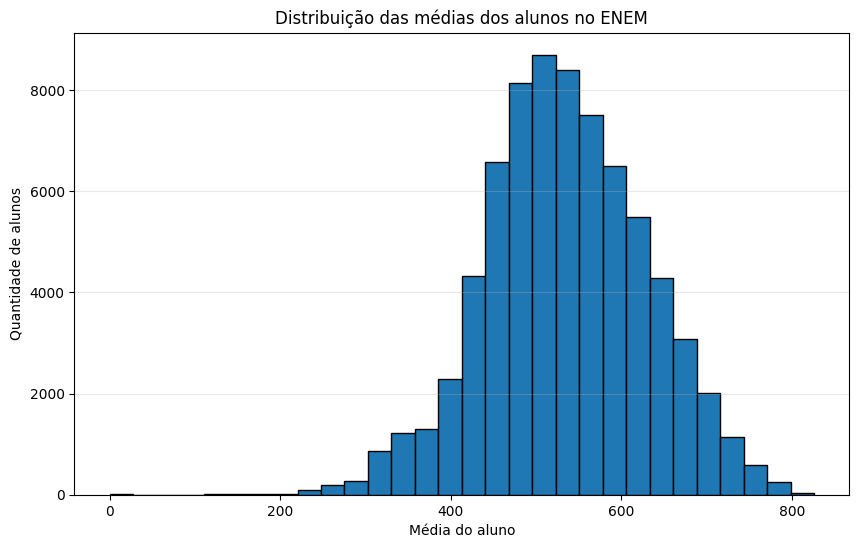

In [18]:
# Esta célula gera um histograma das médias dos alunos.
# O histograma mostra como os valores de MEDIA_ALUNO estão distribuídos.

# Cria uma nova figura.
plt.figure(figsize=(10, 6))

# Cria o histograma.
# bins=30 divide os dados em 30 intervalos.
# edgecolor="black" coloca contorno preto nas barras, melhorando a visualização.
plt.hist(df_validos["MEDIA_ALUNO"], bins=30, edgecolor="black")

# Define título e rótulos dos eixos.
plt.title("Distribuição das médias dos alunos no ENEM")
plt.xlabel("Média do aluno")
plt.ylabel("Quantidade de alunos")

# Adiciona grade horizontal.
plt.grid(axis="y", alpha=0.3)

# Salva o histograma como imagem.
plt.savefig("histograma_medias_alunos.png", dpi=300, bbox_inches="tight")

# Exibe o gráfico no notebook.
plt.show()


# CELULA 15 - Gráfico de dispersão: Matemática x Redação
O gráfico de dispersão permite visualizar a relação entre duas variáveis numéricas. Aqui, comparamos a nota de Matemática com a nota da Redação.


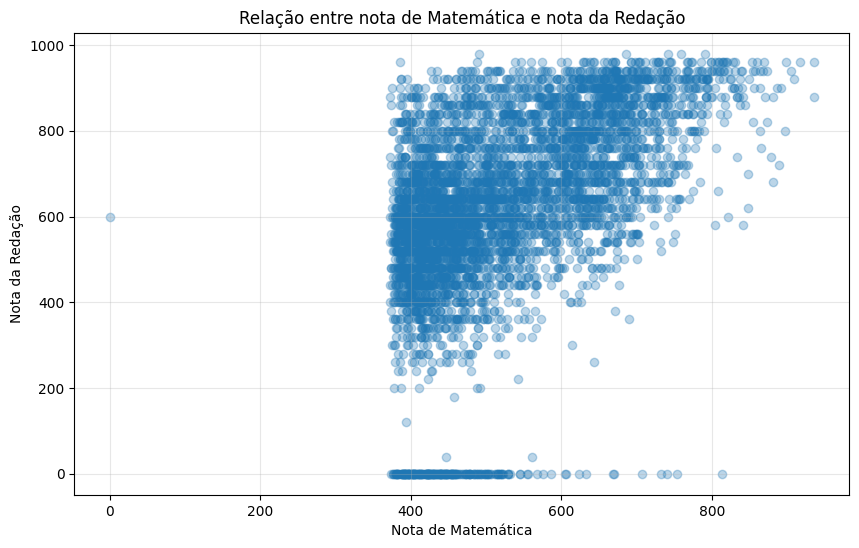

In [19]:
# Esta célula gera um gráfico de dispersão entre Matemática e Redação.
# O gráfico de dispersão é útil para observar a relação entre duas variáveis numéricas.

# Remove linhas sem nota de Matemática ou sem nota de Redação.
amostra = df_validos.dropna(subset=["NU_NOTA_MT", "NU_NOTA_REDACAO"])

# Se houver muitos registros, seleciona uma amostra aleatória de 5000 alunos.
# Isso deixa o gráfico mais leve e evita sobreposição excessiva de pontos.
# random_state=42 garante que a mesma amostra seja selecionada sempre que o código for executado.
if len(amostra) > 5000:
    amostra = amostra.sample(5000, random_state=42)

# Cria uma nova figura.
plt.figure(figsize=(10, 6))

# Cria o gráfico de dispersão.
# Cada ponto representa um aluno.
# Eixo x: nota de Matemática.
# Eixo y: nota da Redação.
# alpha=0.3 deixa os pontos mais transparentes para melhorar a visualização.
plt.scatter(amostra["NU_NOTA_MT"], amostra["NU_NOTA_REDACAO"], alpha=0.3)

# Define título e rótulos dos eixos.
plt.title("Relação entre nota de Matemática e nota da Redação")
plt.xlabel("Nota de Matemática")
plt.ylabel("Nota da Redação")

# Adiciona grade ao gráfico.
plt.grid(alpha=0.3)

# Salva o gráfico como imagem.
plt.savefig("dispersao_matematica_redacao.png", dpi=300, bbox_inches="tight")

# Exibe o gráfico no notebook.
plt.show()


# CELULA 16 - Boxplot: médias por tipo de escola
O boxplot ajuda a comparar a distribuição das médias entre escolas federais, estaduais, municipais e privadas.


C:\Users\enggi\AppData\Local\Temp\ipykernel_6012\2340455447.py:23: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(dados_por_tipo, labels=ordem_tipos)


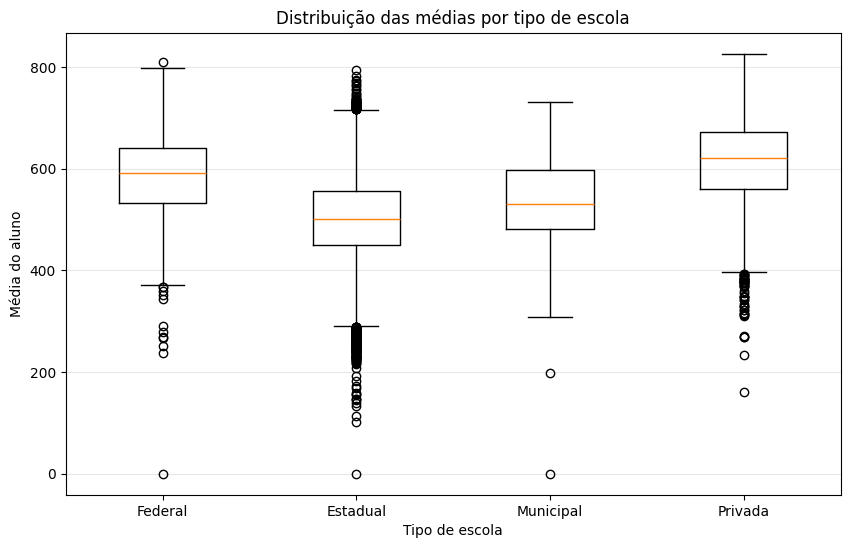

In [20]:
# Esta célula gera um boxplot das médias por tipo de escola.
# O boxplot permite comparar a distribuição das médias entre categorias.
# Ele mostra mediana, dispersão e possíveis valores extremos.

# Remove registros sem tipo de escola ou sem média do aluno.
dados_boxplot = df_validos.dropna(subset=["TIPO_ESCOLA", "MEDIA_ALUNO"])

# Define a ordem em que os tipos de escola aparecerão no gráfico.
ordem_tipos = ["Federal", "Estadual", "Municipal", "Privada"]

# Cria uma lista de séries, uma para cada tipo de escola.
# Cada item da lista contém as médias dos alunos daquele tipo de escola.
dados_por_tipo = [
    dados_boxplot[dados_boxplot["TIPO_ESCOLA"] == tipo]["MEDIA_ALUNO"]
    for tipo in ordem_tipos
]

# Cria uma nova figura.
plt.figure(figsize=(10, 6))

# Cria o boxplot.
# labels define os nomes das categorias mostradas no eixo x.
plt.boxplot(dados_por_tipo, labels=ordem_tipos)

# Define título e rótulos dos eixos.
plt.title("Distribuição das médias por tipo de escola")
plt.xlabel("Tipo de escola")
plt.ylabel("Média do aluno")

# Adiciona grade horizontal.
plt.grid(axis="y", alpha=0.3)

# Salva o gráfico como imagem.
plt.savefig("boxplot_media_tipo_escola.png", dpi=300, bbox_inches="tight")

# Exibe o gráfico no notebook.
plt.show()


# CELULA 17 - Gráfico de pizza: participação dos tipos de escola
O gráfico de pizza mostra a proporção de alunos por tipo de escola no recorte carregado.


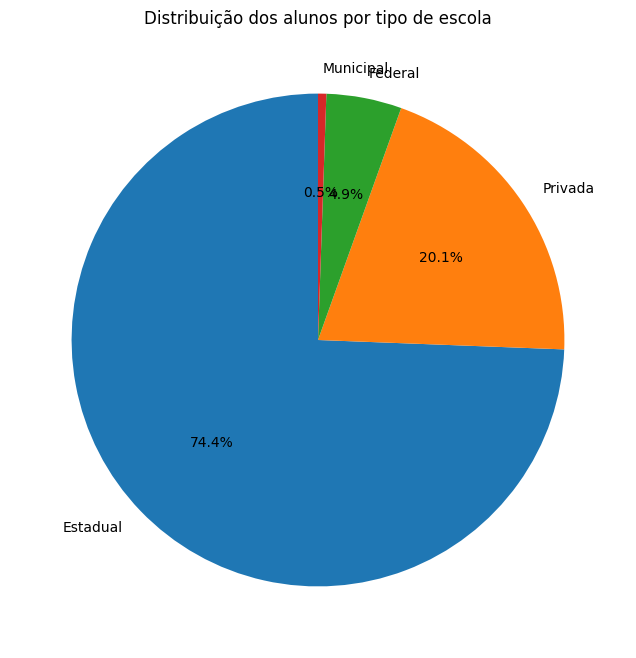

In [21]:
# Esta célula gera um gráfico de pizza com a participação dos tipos de escola.
# O gráfico de pizza mostra a proporção de alunos em cada categoria.

# Conta quantos alunos existem em cada tipo de escola.
# value_counts() retorna a frequência de cada categoria.
# dropna() remove possíveis categorias ausentes.
contagem_tipo = df_validos["TIPO_ESCOLA"].value_counts().dropna()

# Cria uma figura quadrada para o gráfico de pizza.
plt.figure(figsize=(8, 8))

# Cria o gráfico de pizza.
plt.pie(
    contagem_tipo.values,   # Valores numéricos: quantidade de alunos por tipo de escola.
    labels=contagem_tipo.index,  # Rótulos: nomes dos tipos de escola.
    autopct="%1.1f%%",      # Mostra os percentuais com uma casa decimal.
    startangle=90           # Gira o início do gráfico para melhorar a apresentação.
)

# Define o título do gráfico.
plt.title("Distribuição dos alunos por tipo de escola")

# Salva o gráfico como imagem.
plt.savefig("pizza_tipo_escola.png", dpi=300, bbox_inches="tight")

# Exibe o gráfico no notebook.
plt.show()


# CELULA 18 - Gráfico waffle: participação dos tipos de escola
O gráfico waffle representa proporções usando uma grade de quadrados. Aqui, cada quadrado representa aproximadamente 1% dos alunos classificados por tipo de escola.


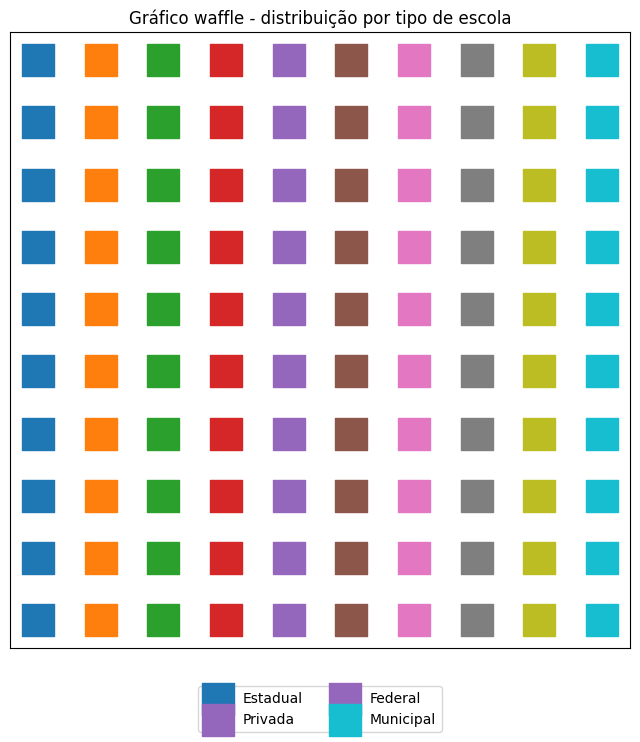

In [22]:
# Esta célula gera um gráfico waffle.
# O gráfico waffle representa proporções usando uma grade, normalmente com 100 quadrados.
# Cada quadrado representa aproximadamente 1% do total.

# Conta a quantidade de alunos por tipo de escola.
contagem_tipo = df_validos["TIPO_ESCOLA"].value_counts().dropna()

# Converte a contagem em percentual.
# Multiplica por 100, arredonda e transforma em número inteiro.
percentuais = (contagem_tipo / contagem_tipo.sum() * 100).round().astype(int)

# Como os percentuais foram arredondados, a soma pode ficar diferente de 100.
# Esta etapa corrige a diferença para garantir que a grade tenha exatamente 100 quadrados.
diferenca = 100 - percentuais.sum()
if len(percentuais) > 0:
    percentuais.iloc[0] += diferenca

# Cria uma lista em que cada categoria aparece repetida conforme sua porcentagem.
# Exemplo: se uma categoria tem 40%, ela aparece 40 vezes na lista.
waffle_dados = []
for categoria, valor in percentuais.items():
    waffle_dados.extend([categoria] * valor)

# Cria a figura e o eixo do gráfico waffle.
fig, ax = plt.subplots(figsize=(8, 8))

# Percorre a lista waffle_dados e posiciona cada quadrado na grade 10 x 10.
for i, categoria in enumerate(waffle_dados):
    linha = i // 10   # Calcula a linha da grade.
    coluna = i % 10   # Calcula a coluna da grade.

    # Desenha um quadrado na posição calculada.
    # marker="s" significa marcador quadrado.
    # s=500 define o tamanho do marcador.
    # A lógica do label evita repetir a mesma categoria várias vezes na legenda.
    ax.scatter(
        coluna,
        9 - linha,
        marker="s",
        s=500,
        label=categoria if categoria not in waffle_dados[:i] else ""
    )

# Define o título do gráfico.
ax.set_title("Gráfico waffle - distribuição por tipo de escola")

# Remove marcações dos eixos, pois o waffle não precisa mostrar valores de x e y.
ax.set_xticks([])
ax.set_yticks([])

# Posiciona a legenda abaixo do gráfico.
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.05), ncol=2)

# Salva o gráfico como imagem.
plt.savefig("waffle_tipo_escola.png", dpi=300, bbox_inches="tight")

# Exibe o gráfico no notebook.
plt.show()


# CELULA 19 - Heatmap: média das notas por tipo de escola
O heatmap permite comparar, em formato de mapa de calor, as médias das provas específicas para cada tipo de escola.


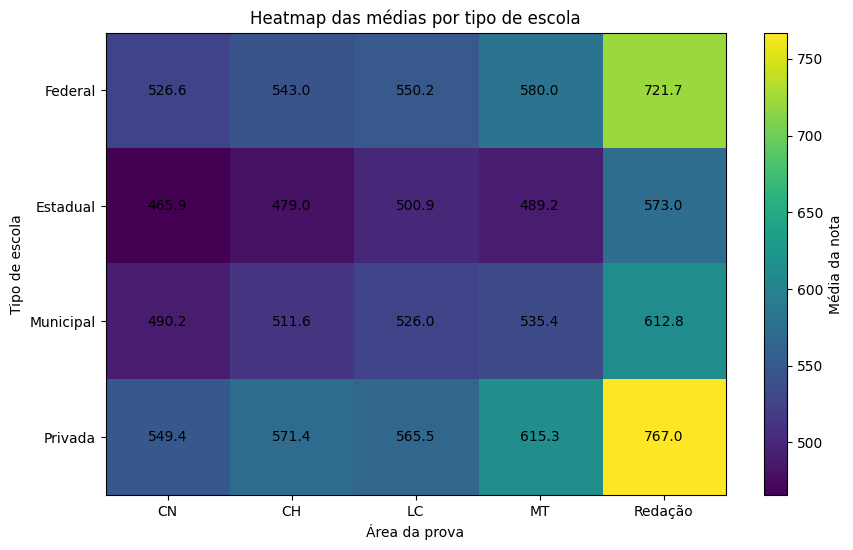

In [23]:
# Esta célula gera um heatmap com a média das notas por tipo de escola.
# O heatmap é uma matriz visual em que os valores são representados por intensidade de cor.

# Calcula a média de cada prova para cada tipo de escola.
media_notas_tipo = (
    df_validos
    # Remove registros sem tipo de escola.
    .dropna(subset=["TIPO_ESCOLA"])

    # Agrupa os alunos por tipo de escola.
    .groupby("TIPO_ESCOLA")[["NU_NOTA_CN", "NU_NOTA_CH", "NU_NOTA_LC", "NU_NOTA_MT", "NU_NOTA_REDACAO"]]

    # Calcula a média de cada nota dentro de cada tipo de escola.
    .mean()

    # Reorganiza as linhas na ordem definida anteriormente.
    .reindex(ordem_tipos)
)

# Cria uma nova figura.
plt.figure(figsize=(10, 6))

# Cria o heatmap usando imshow().
# aspect="auto" ajusta automaticamente a proporção da imagem.
plt.imshow(media_notas_tipo, aspect="auto")

# Adiciona uma barra lateral indicando a escala das médias.
plt.colorbar(label="Média da nota")

# Define título e rótulos dos eixos.
plt.title("Heatmap das médias por tipo de escola")
plt.xlabel("Área da prova")
plt.ylabel("Tipo de escola")

# Define os rótulos do eixo x.
plt.xticks(
    ticks=range(len(media_notas_tipo.columns)),
    labels=["CN", "CH", "LC", "MT", "Redação"]
)

# Define os rótulos do eixo y.
plt.yticks(
    ticks=range(len(media_notas_tipo.index)),
    labels=media_notas_tipo.index
)

# Escreve o valor médio dentro de cada célula do heatmap.
for i in range(media_notas_tipo.shape[0]):      # Percorre as linhas: tipos de escola.
    for j in range(media_notas_tipo.shape[1]):  # Percorre as colunas: provas.
        valor = media_notas_tipo.iloc[i, j]

        # Só escreve o valor se ele não for NaN.
        if not np.isnan(valor):
            plt.text(j, i, f"{valor:.1f}", ha="center", va="center")

# Salva o gráfico como imagem.
plt.savefig("heatmap_notas_tipo_escola.png", dpi=300, bbox_inches="tight")

# Exibe o gráfico no notebook.
plt.show()


# CELULA 20 - Subplots: comparação das distribuições das provas
Os subplots permitem colocar vários gráficos em uma mesma figura. Aqui, são mostrados histogramas das notas das provas específicas e da redação.


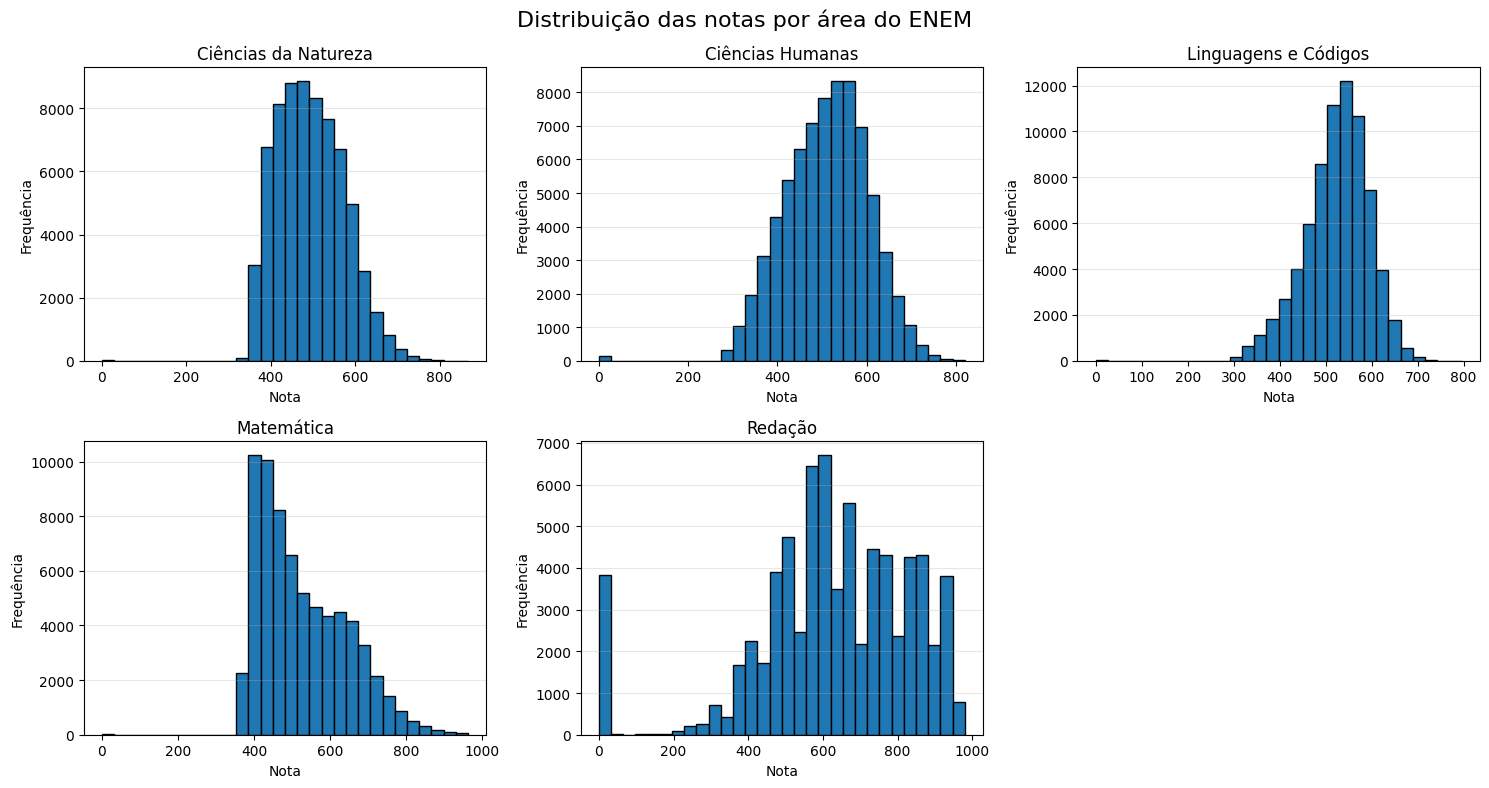

In [24]:
# Esta célula gera subplots com histogramas das notas de cada prova.
# Subplots permitem colocar vários gráficos dentro de uma mesma figura.

# Cria uma grade de gráficos com 2 linhas e 3 colunas.
# Como existem 5 provas, o sexto espaço será removido depois.
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

# Converte a matriz de eixos em uma lista simples.
# Isso facilita percorrer os gráficos usando um laço for.
axes = axes.flatten()

# Dicionário com nomes mais descritivos para as provas.
nomes_provas = {
    "NU_NOTA_CN": "Ciências da Natureza",
    "NU_NOTA_CH": "Ciências Humanas",
    "NU_NOTA_LC": "Linguagens e Códigos",
    "NU_NOTA_MT": "Matemática",
    "NU_NOTA_REDACAO": "Redação"
}

# Percorre as colunas de notas e cria um histograma para cada uma.
for i, coluna in enumerate(colunas_notas):
    # Cria o histograma da prova atual.
    # dropna() remove valores ausentes antes de montar o gráfico.
    axes[i].hist(df_validos[coluna].dropna(), bins=30, edgecolor="black")

    # Define título e rótulos de cada subplot.
    axes[i].set_title(nomes_provas[coluna])
    axes[i].set_xlabel("Nota")
    axes[i].set_ylabel("Frequência")

    # Adiciona grade horizontal ao subplot.
    axes[i].grid(axis="y", alpha=0.3)

# Remove o sexto subplot, pois a grade possui 6 espaços, mas o ENEM possui 5 notas analisadas.
fig.delaxes(axes[5])

# Define um título geral para a figura inteira.
plt.suptitle("Distribuição das notas por área do ENEM", fontsize=16)

# Ajusta automaticamente os espaços entre os subplots.
plt.tight_layout()

# Salva a figura como imagem.
plt.savefig("subplots_distribuicao_notas.png", dpi=300, bbox_inches="tight")

# Exibe a figura no notebook.
plt.show()


# CELULA 21 - Conclusão do projeto
O notebook realizou a leitura parcial dos microdados do ENEM, selecionando colunas associadas às notas, escola, município, UF e dependência administrativa. Em seguida, foram tratados dados ausentes, calculada a média por aluno e produzidos rankings por aluno, escola, município e UF. Por fim, foram gerados gráficos com `matplotlib`, contemplando diferentes visualizações trabalhadas na Aula 07: barras, histograma, dispersão, boxplot, pizza, waffle, heatmap, subplots e exportação das figuras com `savefig()`.
